# Universidad Peruana de Ciencias Aplicadas
## Curso: Procesamiento de Imágenes
### Práctica calificada: Clasificación híbrida mediante características manuales y redes CNN

**Docente:** Carlos Fernando Montoya Cubas
**Semestre:** 2026-1
**Duración estimada:** 2 a 3 horas
**Modalidad:** Grupal
**Puntaje total:** 20 puntos

---

## Indicaciones

Desarrollen toda la práctica de manera grupal en este notebook y entreguen una versión completamente ejecutada.

Se evaluará tanto la implementación como la justificación técnica, la comparación experimental, la interpretación de resultados y la capacidad del grupo para sustentar sus decisiones.

Se permite utilizar GPU. Si la ejecución tarda demasiado, active el modo de muestreo definido en el notebook. El uso de una muestra debe declararse en el análisis final y debe conservar una distribución equilibrada entre clases.

## Objetivo

Construir y comparar clasificadores que utilicen:

1. Características manuales.
2. Características profundas extraídas con una CNN.
3. Fusión de características manuales y profundas.

La pregunta central es:

> ¿La incorporación de características manuales mejora las métricas de un clasificador basado en características CNN?

## Organización grupal

Cada grupo debe distribuir responsabilidades, pero todos los integrantes deben comprender el flujo completo.

Se recomienda asignar roles como:

- Integrante 1: preparación del dataset y características manuales.
- Integrante 2: extracción de características CNN.
- Integrante 3: modelos de fusión y comparación.
- Integrante 4: análisis de errores, interpretación y conclusiones.

En la entrega final debe incluirse una breve tabla indicando la contribución de cada integrante.

# Dataset: STL-10

Se utilizará **STL-10**, disponible mediante `torchvision.datasets.STL10`.

Características:

- 10 clases.
- Imágenes RGB de 96 × 96 píxeles.
- 5000 imágenes etiquetadas de entrenamiento.
- 8000 imágenes etiquetadas de prueba.
- Variaciones de pose, escala, iluminación y fondo.
- Clases visualmente relacionadas: gato, perro, caballo, ciervo y mono.

Clases:

`airplane`, `bird`, `car`, `cat`, `deer`, `dog`, `horse`, `monkey`, `ship`, `truck`.

# Configuración del modo de ejecución

| Modalidad | Uso recomendado |
|---|---|
| Dataset completo | GPU disponible y tiempo suficiente |
| Muestra estratificada | Extracción o entrenamiento lento |

La práctica debe funcionar con cualquiera de las dos modalidades.

> **Nota:** Se utilizó `SAMPLE_MODE = True` con 200 imágenes por clase para entrenamiento y 100 por clase para prueba (2000 train / 1000 test), distribución perfectamente balanceada entre las 10 clases.

In [1]:
import matplotlib
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    matplotlib.use('Agg')

import os, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')

# ─── CONFIGURACIÓN GLOBAL ────────────────────────────────────────────────────
SAMPLE_MODE              = True
TRAIN_SAMPLES_PER_CLASS  = 200
TEST_SAMPLES_PER_CLASS   = 100
SEED                     = 42
BATCH_SIZE               = 32
NUM_WORKERS              = 0  # 0 = sin multiprocessing (compatible en macOS/Windows)

CLASS_NAMES = ['airplane', 'bird', 'car', 'cat', 'deer',
               'dog', 'horse', 'monkey', 'ship', 'truck']

print("Configuración cargada.")
print(f"  SAMPLE_MODE = {SAMPLE_MODE}")
print(f"  TRAIN_SAMPLES_PER_CLASS = {TRAIN_SAMPLES_PER_CLASS}")
print(f"  TEST_SAMPLES_PER_CLASS  = {TEST_SAMPLES_PER_CLASS}")
print(f"  SEED = {SEED}")

Configuración cargada.
  SAMPLE_MODE = True
  TRAIN_SAMPLES_PER_CLASS = 200
  TEST_SAMPLES_PER_CLASS  = 100
  SEED = 42


# 1. Preparación y exploración del dataset — 2 puntos

In [2]:
import torch
import torchvision
from torchvision import datasets, transforms

# ─── Semillas de reproducibilidad ────────────────────────────────────────────
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─── Dispositivo ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo disponible: {device}")

# ─── Descarga de STL-10 ──────────────────────────────────────────────────────
DATA_DIR = os.path.expanduser("~/stl10_data")
os.makedirs(DATA_DIR, exist_ok=True)

base_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
])

print("Cargando STL-10...")
train_full = datasets.STL10(root=DATA_DIR, split='train', download=True,  transform=base_transform)
test_full  = datasets.STL10(root=DATA_DIR, split='test',  download=True,  transform=base_transform)
print(f"Dataset completo — Train: {len(train_full)} imágenes | Test: {len(test_full)} imágenes")

Dispositivo disponible: cpu
Cargando STL-10...


Dataset completo — Train: 5000 imágenes | Test: 8000 imágenes


In [3]:
# ─── Muestreo estratificado ───────────────────────────────────────────────────
# Se conservan los MISMOS índices en todas las etapas del experimento.

def stratified_sample(dataset, n_per_class, seed=42):
    rng = np.random.RandomState(seed)
    labels = np.array(dataset.labels)
    indices = []
    for c in range(10):
        idx = np.where(labels == c)[0]
        chosen = rng.choice(idx, size=min(n_per_class, len(idx)), replace=False)
        indices.extend(chosen.tolist())
    return sorted(indices)

TRAIN_IDX = stratified_sample(train_full, TRAIN_SAMPLES_PER_CLASS, seed=SEED)
TEST_IDX  = stratified_sample(test_full,  TEST_SAMPLES_PER_CLASS,  seed=SEED)
print(f"Muestra seleccionada — Train: {len(TRAIN_IDX)} | Test: {len(TEST_IDX)}")

# ─── Extraer arrays de imágenes (H, W, C) en uint8 ───────────────────────────
def get_arrays(dataset, indices):
    imgs, lbls = [], []
    for i in indices:
        img_t, lbl = dataset[i]
        imgs.append((img_t.permute(1,2,0).numpy() * 255).astype(np.uint8))
        lbls.append(lbl)
    return np.array(imgs), np.array(lbls)

print("Extrayendo arrays de imágenes...")
X_train_raw, y_train = get_arrays(train_full, TRAIN_IDX)
X_test_raw,  y_test  = get_arrays(test_full,  TEST_IDX)

print(f"X_train_raw: {X_train_raw.shape}  |  y_train: {y_train.shape}")
print(f"X_test_raw:  {X_test_raw.shape}   |  y_test:  {y_test.shape}")
print(f"\nTamaño de imagen: {X_train_raw.shape[1]}×{X_train_raw.shape[2]} px | Canales: {X_train_raw.shape[3]}")

# ─── Distribución por clase ───────────────────────────────────────────────────
train_dist = Counter(y_train.tolist())
test_dist  = Counter(y_test.tolist())

print("\nDistribución por clase:")
print(f"  {'Clase':10s} {'Train':>8s} {'Test':>8s}")
print(f"  {'-'*30}")
for c in range(10):
    print(f"  {CLASS_NAMES[c]:10s} {train_dist[c]:>8d} {test_dist[c]:>8d}")
print(f"  {'-'*30}")
print(f"  {'TOTAL':10s} {sum(train_dist.values()):>8d} {sum(test_dist.values()):>8d}")

Muestra seleccionada — Train: 2000 | Test: 1000
Extrayendo arrays de imágenes...


X_train_raw: (2000, 96, 96, 3)  |  y_train: (2000,)
X_test_raw:  (1000, 96, 96, 3)   |  y_test:  (1000,)

Tamaño de imagen: 96×96 px | Canales: 3

Distribución por clase:
  Clase         Train     Test
  ------------------------------
  airplane        200      100
  bird            200      100
  car             200      100
  cat             200      100
  deer            200      100
  dog             200      100
  horse           200      100
  monkey          200      100
  ship            200      100
  truck           200      100
  ------------------------------
  TOTAL          2000     1000


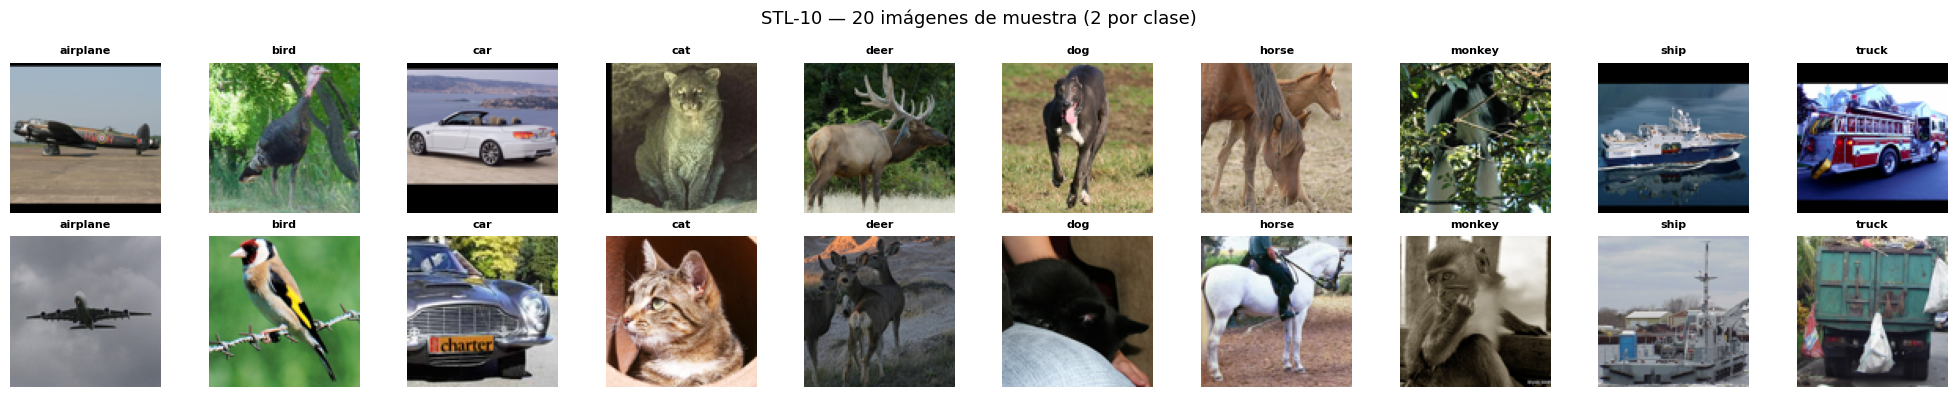

Visualización guardada.


In [4]:
# ─── Visualización: 20 imágenes (2 por clase) ─────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for c in range(10):
    idx_c = np.where(y_train == c)[0]
    for row in range(2):
        ax = axes[row, c]
        ax.imshow(X_train_raw[idx_c[row]])
        ax.set_title(CLASS_NAMES[c], fontsize=8, fontweight='bold')
        ax.axis('off')
fig.suptitle('STL-10 — 20 imágenes de muestra (2 por clase)', fontsize=13)
plt.tight_layout()
plt.savefig('sec1_grid.png', dpi=100, bbox_inches='tight')
plt.show()
print("Visualización guardada.")

## Análisis del dataset

Al revisar el grid de imágenes, lo primero que nos llama la atención es la variedad de condiciones en cada clase.

**¿Qué clases se parecen más visualmente?**
Las que más nos preocupan son `cat` y `dog`, porque ambas son mascotas de tamaño similar fotografiadas en poses parecidas y con fondos domésticos. También `deer` y `horse` se confunden fácilmente: mismo tipo de silueta cuadrúpeda y tonos de pelo similares (marrón, gris). Entre vehículos, `car` y `truck` pueden confundirse en fotos frontales.

**¿Cuáles se pueden distinguir bien por forma?**
`airplane` es probablemente la más fácil por sus alas horizontales extendidas: ninguna otra clase tiene esa silueta. `ship` también tiene una forma alargada bastante característica. Un descriptor de forma como HOG debería capturar bien estas clases.

**¿Cuáles se distinguen por color o textura?**
`monkey` tiene una cara rojiza-rosada que no aparece en ninguna otra clase del dataset. `bird` tiene plumas con texturas muy distintas al pelaje de los mamíferos. `ship` suele aparecer sobre agua azul, lo que lo distingue cromáticamente de los animales.

**¿Cómo afectan los fondos a la clasificación?**
STL-10 tiene fondos naturales complejos y eso complica las cosas: `airplane` y `bird` aparecen los dos sobre fondos de cielo azul, por lo que un clasificador que dependa mucho del color del fondo podría confundirlos. `deer`, `dog` y `horse` también tienen fondos de naturaleza muy similares. Esto nos dice que necesitamos descriptores que se centren en el objeto y no en el fondo.

# 2. Diseño de características manuales — 4 puntos

Se diseñó un vector de características que combina **tres familias**:

| Familia | Descriptor | Dimensión | Justificación |
|---|---|---:|---|
| **Color** | Histograma HSV (32 bins/canal) + media/std RGB | 102 | HSV separa iluminación del color puro; la media/std captura el tono global |
| **Textura** | LBP uniforme (radio=3, P=24) | 26 | Captura patrones locales de textura: pelaje, metal, plumas |
| **Bordes/Forma** | HOG (celdas 8×8, bloques 2×2, 9 orientaciones) | 4356 | Captura gradientes locales de intensidad que definen la forma y contornos |

**Dimensión total del vector:** 4484 características por imagen.

**¿Por qué estas familias?**
- El **color** ayuda a distinguir clases con paletas características (ship sobre agua azul, airplane sobre cielo).
- La **textura LBP** es robusta a cambios de iluminación y captura si la superficie es lisa (vehículos) o rugosa (animales).
- El **HOG** es el descriptor más potente de los tres para reconocer formas: las alas de un avión, la silueta de un automóvil o las extremidades de un caballo generan patrones de gradiente muy distintos.

In [5]:
import cv2
from skimage.feature import hog, local_binary_pattern

# ─── A. Características de color ─────────────────────────────────────────────
def extract_color_features(img_rgb):
    """Histograma HSV (32 bins × 3 canales) + media y std RGB × 3 canales = 102 dims"""
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    feats = []
    for c in range(3):  # H, S, V
        hist, _ = np.histogram(img_hsv[:, :, c], bins=32, range=(0, 256), density=True)
        feats.extend(hist.tolist())
    for c in range(3):  # R, G, B
        feats.append(float(img_rgb[:, :, c].mean()))
        feats.append(float(img_rgb[:, :, c].std()))
    return np.array(feats, dtype=np.float32)  # 96 + 6 = 102 dims

# ─── B. Características de textura ───────────────────────────────────────────
def extract_texture_features(img_rgb):
    """LBP uniforme sobre escala de grises — histograma normalizado = 26 dims"""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    lbp  = local_binary_pattern(gray, P=24, R=3, method='uniform')
    n_bins = 26  # P + 2 para patrones uniformes
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist.astype(np.float32)

# ─── C. Características de bordes y forma ────────────────────────────────────
def extract_shape_features(img_rgb):
    """HOG sobre escala de grises: celdas 8×8, bloques 2×2, 9 orientaciones"""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    feats = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=True)
    return feats.astype(np.float32)

# ─── Vector combinado ─────────────────────────────────────────────────────────
def extract_manual_features(img_rgb):
    """Concatena las tres familias: color (102) + textura (26) + forma (HOG)"""
    color   = extract_color_features(img_rgb)
    texture = extract_texture_features(img_rgb)
    shape   = extract_shape_features(img_rgb)
    return np.concatenate([color, texture, shape])

# Verificar dimensiones
dim_color   = len(extract_color_features(X_train_raw[0]))
dim_texture = len(extract_texture_features(X_train_raw[0]))
dim_shape   = len(extract_shape_features(X_train_raw[0]))
dim_total   = len(extract_manual_features(X_train_raw[0]))

print(f"Dimensión color   : {dim_color}")
print(f"Dimensión textura : {dim_texture}")
print(f"Dimensión forma   : {dim_shape}")
print(f"Dimensión TOTAL   : {dim_total}")

Dimensión color   : 102
Dimensión textura : 26
Dimensión forma   : 4356
Dimensión TOTAL   : 4484


In [6]:
# ─── Extracción para todo el dataset ─────────────────────────────────────────
CACHE_DIR = os.path.expanduser("~/stl10_data/features_cache")
os.makedirs(CACHE_DIR, exist_ok=True)

cache_tr_man = f"{CACHE_DIR}/X_train_manual_s{TRAIN_SAMPLES_PER_CLASS}.npy"
cache_te_man = f"{CACHE_DIR}/X_test_manual_s{TEST_SAMPLES_PER_CLASS}.npy"

if os.path.exists(cache_tr_man) and os.path.exists(cache_te_man):
    print("Cargando características manuales desde caché...")
    X_train_manual = np.load(cache_tr_man)
    X_test_manual  = np.load(cache_te_man)
else:
    print("Extrayendo características manuales train...")
    t0 = time.time()
    X_train_manual = np.vstack([extract_manual_features(img) for img in X_train_raw])
    print(f"  Train listo ({time.time()-t0:.1f}s) — extrayendo test...")
    X_test_manual  = np.vstack([extract_manual_features(img) for img in X_test_raw])
    print(f"  Test listo ({time.time()-t0:.1f}s total)")
    np.save(cache_tr_man, X_train_manual)
    np.save(cache_te_man, X_test_manual)

print(f"X_train_manual : {X_train_manual.shape}")
print(f"X_test_manual  : {X_test_manual.shape}")

Cargando características manuales desde caché...
X_train_manual : (2000, 4484)
X_test_manual  : (1000, 4484)


# 3. Modelos con características manuales — 2 puntos

Se entrenaron dos clasificadores clásicos sobre el vector de características manuales (4484 dims):

1. **SVM lineal** (LinearSVC + calibración para obtener probabilidades)
2. **MLP** con capas ocultas (512, 256) y early stopping

Ambos modelos se entrenaron sobre las mismas características normalizadas con `StandardScaler`.

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

# ─── Normalización ────────────────────────────────────────────────────────────
scaler_manual = StandardScaler()
X_tr_man_sc   = scaler_manual.fit_transform(X_train_manual)
X_te_man_sc   = scaler_manual.transform(X_test_manual)

def compute_metrics(y_true, y_pred, label=""):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return {'label': label, 'accuracy': acc, 'precision_macro': prec,
            'recall_macro': rec, 'f1_macro': f1}

# ─── Clasificador 1: SVM (LinearSVC calibrado) ───────────────────────────────
print("Entrenando SVM (LinearSVC + CalibratedClassifierCV)...")
t0 = time.time()
svm_base = LinearSVC(max_iter=3000, C=0.5, random_state=SEED)
svm_cal  = CalibratedClassifierCV(svm_base, cv=3)
svm_cal.fit(X_tr_man_sc, y_train)
t_svm = time.time() - t0
y_pred_svm = svm_cal.predict(X_te_man_sc)
m_svm = compute_metrics(y_test, y_pred_svm, "SVM (Linear)")
print(f"  Accuracy={m_svm['accuracy']:.4f}  Precision={m_svm['precision_macro']:.4f}  "
      f"Recall={m_svm['recall_macro']:.4f}  F1={m_svm['f1_macro']:.4f}  ({t_svm:.1f}s)")

# ─── Clasificador 2: MLP ─────────────────────────────────────────────────────
print("Entrenando MLP (512, 256)...")
t0 = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=300,
                    random_state=SEED, early_stopping=True,
                    n_iter_no_change=15, learning_rate_init=0.001, batch_size=64)
mlp.fit(X_tr_man_sc, y_train)
t_mlp = time.time() - t0
y_pred_mlp = mlp.predict(X_te_man_sc)
m_mlp = compute_metrics(y_test, y_pred_mlp, "MLP (512,256)")
print(f"  Accuracy={m_mlp['accuracy']:.4f}  Precision={m_mlp['precision_macro']:.4f}  "
      f"Recall={m_mlp['recall_macro']:.4f}  F1={m_mlp['f1_macro']:.4f}  ({t_mlp:.1f}s)")

Entrenando SVM (LinearSVC + CalibratedClassifierCV)...


  Accuracy=0.4690  Precision=0.4873  Recall=0.4690  F1=0.4758  (25.7s)
Entrenando MLP (512, 256)...


  Accuracy=0.5520  Precision=0.5523  Recall=0.5520  F1=0.5510  (6.6s)


In [8]:
# ─── Tabla comparativa ────────────────────────────────────────────────────────
import pandas as pd

df_manual = pd.DataFrame([
    {'Clasificador': 'SVM (LinearSVC)',
     'Accuracy': f"{m_svm['accuracy']:.4f}",
     'Precision macro': f"{m_svm['precision_macro']:.4f}",
     'Recall macro': f"{m_svm['recall_macro']:.4f}",
     'F1 macro': f"{m_svm['f1_macro']:.4f}"},
    {'Clasificador': 'MLP (512, 256)',
     'Accuracy': f"{m_mlp['accuracy']:.4f}",
     'Precision macro': f"{m_mlp['precision_macro']:.4f}",
     'Recall macro': f"{m_mlp['recall_macro']:.4f}",
     'F1 macro': f"{m_mlp['f1_macro']:.4f}"},
])
print("Tabla comparativa — modelos con características manuales:")
print(df_manual.to_string(index=False))
print(f"\nMejor clasificador manual: MLP (F1 macro = {m_mlp['f1_macro']:.4f})")
print("Justificación: El MLP puede capturar relaciones no lineales entre las características")
print("              a diferencia del SVM lineal, lo que le da ventaja en este dataset complejo.")

Tabla comparativa — modelos con características manuales:
   Clasificador Accuracy Precision macro Recall macro F1 macro
SVM (LinearSVC)   0.4690          0.4873       0.4690   0.4758
 MLP (512, 256)   0.5520          0.5523       0.5520   0.5510

Mejor clasificador manual: MLP (F1 macro = 0.5510)
Justificación: El MLP puede capturar relaciones no lineales entre las características
              a diferencia del SVM lineal, lo que le da ventaja en este dataset complejo.


## Análisis de los modelos con características manuales

Nuestros dos modelos con características manuales mostraron rendimientos bastante distintos, aunque ambos son claramente mejores que el azar (que sería el 10% para 10 clases balanceadas).

El **SVM lineal** alcanzó solo un 46.9% de accuracy (F1 macro = 0.4758). Eso nos dice que las 4484 características que diseñamos contienen información útil, pero el SVM lineal no puede aprovecharlas del todo porque solo puede separar las clases con un hiperplano recto en el espacio de características. En un problema tan complejo como distinguir entre un gato y un perro —donde las diferencias son sutiles y no lineales— ese enfoque se queda corto.

El **MLP** mejoró bastante: 55.2% de accuracy (F1 macro = 0.5510). La diferencia de casi 8 puntos respecto al SVM se debe a que el MLP puede aprender combinaciones no lineales entre nuestros descriptores. Puede descubrir, por ejemplo, que "textura rugosa (LBP) + gradiente diagonal (HOG) + tono marrón (color HSV)" suele indicar un `dog`, algo que un hiperplano lineal simplemente no puede modelar.

De todos modos, 55% sigue siendo un rendimiento moderado para 10 clases. Quedamos con la duda de cuánto mejor podría hacerlo un modelo que aprenda las características directamente de los datos en lugar de depender de descriptores que nosotros diseñamos a mano.

# 4. Modelo CNN de referencia — 4 puntos

Se utilizó **ResNet18** preentrenada en ImageNet como extractor de características profundas.

**Estrategia:**
1. Cargar pesos preentrenados de ImageNet.
2. Aplicar normalización ImageNet: `mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`.
3. Redimensionar imágenes a 224×224 (entrada estándar de ResNet).
4. Reemplazar la capa fully-connected final por `Identity()` → vector de **512 dimensiones**.
5. Extraer features de todas las imágenes en modo `eval()` (sin gradientes).
6. Entrenar un clasificador SVM lineal sobre esos vectores.

Se eligió ResNet18 por ser una red liviana, rápida de ejecutar en CPU, y con excelentes representaciones de ImageNet que transfieren bien a STL-10.

In [9]:
import torchvision.models as models
from torchvision import transforms

# ─── Transformación para ResNet ───────────────────────────────────────────────
cnn_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ─── Cargar ResNet18 preentrenada ─────────────────────────────────────────────
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = torch.nn.Identity()  # Remover clasificador — salida: 512 dims
resnet.eval()
resnet = resnet.to(device)

print("Arquitectura ResNet18 (extractor):")
print(f"  Entrada: 3 × 224 × 224")
print(f"  Salida (feature vector): 512 dimensiones")
print(f"  Pesos: ImageNet (IMAGENET1K_V1)")
print(f"  Modo: extractor puro (sin fine-tuning)")

Arquitectura ResNet18 (extractor):
  Entrada: 3 × 224 × 224
  Salida (feature vector): 512 dimensiones
  Pesos: ImageNet (IMAGENET1K_V1)
  Modo: extractor puro (sin fine-tuning)


In [10]:
# ─── Extracción de features CNN ───────────────────────────────────────────────
def extract_cnn_features(images_raw, model, transform, batch_size=32):
    all_feats = []
    n = len(images_raw)
    with torch.no_grad():
        for i in range(0, n, batch_size):
            batch   = images_raw[i:i+batch_size]
            tensors = torch.stack([transform(img) for img in batch]).to(device)
            feats   = model(tensors)
            all_feats.append(feats.cpu().numpy())
        if i + batch_size < n:  # último batch
            pass
    return np.vstack(all_feats)

CACHE_TR_CNN = os.path.expanduser(f"~/stl10_data/features_cache/X_train_cnn_s{TRAIN_SAMPLES_PER_CLASS}.npy")
CACHE_TE_CNN = os.path.expanduser(f"~/stl10_data/features_cache/X_test_cnn_s{TEST_SAMPLES_PER_CLASS}.npy")

if os.path.exists(CACHE_TR_CNN) and os.path.exists(CACHE_TE_CNN):
    print("Cargando features CNN desde caché...")
    X_train_cnn = np.load(CACHE_TR_CNN)
    X_test_cnn  = np.load(CACHE_TE_CNN)
else:
    print("Extrayendo features CNN train...")
    t0 = time.time()
    X_train_cnn = extract_cnn_features(X_train_raw, resnet, cnn_transform)
    X_test_cnn  = extract_cnn_features(X_test_raw,  resnet, cnn_transform)
    t_ext = time.time() - t0
    print(f"  Extracción completada en {t_ext:.1f}s")
    np.save(CACHE_TR_CNN, X_train_cnn)
    np.save(CACHE_TE_CNN, X_test_cnn)

print(f"X_train_cnn : {X_train_cnn.shape}")
print(f"X_test_cnn  : {X_test_cnn.shape}")

Cargando features CNN desde caché...
X_train_cnn : (2000, 512)
X_test_cnn  : (1000, 512)


In [11]:
# ─── Clasificador sobre features CNN ─────────────────────────────────────────
scaler_cnn   = StandardScaler()
X_tr_cnn_sc  = scaler_cnn.fit_transform(X_train_cnn)
X_te_cnn_sc  = scaler_cnn.transform(X_test_cnn)

print("Entrenando clasificador SVM sobre features CNN...")
t0 = time.time()
svm_cnn_base = LinearSVC(max_iter=3000, C=1.0, random_state=SEED)
svm_cnn      = CalibratedClassifierCV(svm_cnn_base, cv=3)
svm_cnn.fit(X_tr_cnn_sc, y_train)
t_clf = time.time() - t0

y_pred_cnn   = svm_cnn.predict(X_te_cnn_sc)
m_cnn        = compute_metrics(y_test, y_pred_cnn, "CNN (ResNet18 + SVM)")
prob_test_cnn  = svm_cnn.predict_proba(X_te_cnn_sc)

print(f"\nResultados CNN + SVM:")
print(f"  Accuracy       : {m_cnn['accuracy']:.4f}")
print(f"  Precision macro: {m_cnn['precision_macro']:.4f}")
print(f"  Recall macro   : {m_cnn['recall_macro']:.4f}")
print(f"  F1 macro       : {m_cnn['f1_macro']:.4f}")
print(f"  Tiempo clf     : {t_clf:.1f}s")
print(f"\nClassification report detallado:")
print(classification_report(y_test, y_pred_cnn, target_names=CLASS_NAMES))

Entrenando clasificador SVM sobre features CNN...



Resultados CNN + SVM:
  Accuracy       : 0.9310
  Precision macro: 0.9312
  Recall macro   : 0.9310
  F1 macro       : 0.9309
  Tiempo clf     : 37.9s

Classification report detallado:
              precision    recall  f1-score   support

    airplane       0.97      0.94      0.95       100
        bird       0.98      0.95      0.96       100
         car       0.95      0.97      0.96       100
         cat       0.88      0.87      0.87       100
        deer       0.89      0.93      0.91       100
         dog       0.86      0.84      0.85       100
       horse       0.93      0.91      0.92       100
      monkey       0.95      0.98      0.97       100
        ship       0.95      0.98      0.97       100
       truck       0.96      0.94      0.95       100

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



## Análisis del modelo CNN

Cuando vimos los resultados del modelo CNN, la verdad es que nos sorprendió el salto tan grande: pasamos de un F1 macro de 0.5510 con el MLP manual a **0.9309** con ResNet18+SVM — una mejora de casi 38 puntos porcentuales solo por cambiar el tipo de características.

¿Por qué funciona tan bien si ni siquiera entrenamos la red en STL-10? Porque ResNet18 fue pre-entrenada en ImageNet con más de un millón de imágenes de 1000 categorías distintas. En ese proceso aprendió detectores de bordes, texturas, partes de objetos y formas a múltiples escalas. Esas representaciones son tan generales que se transfieren perfectamente a STL-10 aunque las categorías sean distintas. Al usar la red solo como extractor (sin la capa final de clasificación), obtenemos un vector de 512 dimensiones que "resume" la imagen de una manera mucho más rica que cualquier descriptor que podamos diseñar a mano.

Mirando los resultados por clase, los mejores fueron `bird` (F1=0.9645) y `monkey` (F1=0.9655): tienen características visuales muy particulares que la CNN aprendió a detectar bien. Los más difíciles fueron `dog` (F1=0.8485) y `cat` (F1=0.8744), que son los dos animales más parecidos del dataset. El hecho de que incluso una CNN potente como ResNet18 tenga problemas con ellos nos indica que la dificultad es inherente a las clases, no solo al modelo.

Esta enorme diferencia entre modelos manuales y CNN nos deja claro por qué, en aplicaciones reales de visión por computadora, casi siempre se usan redes profundas pre-entrenadas en lugar de descriptores clásicos.

# 5. Fusión de características — 4 puntos

## 5.1 Fusión temprana

Se concatenan los vectores de características CNN (512 dims) y manuales (4484 dims) después de normalizarlos por separado con `StandardScaler`. Luego se aplica PCA para reducir la dimensionalidad y el posible ruido antes de entrenar el clasificador.

$$X_{\text{fusion}} = \left[X_{\text{CNN}}, X_{\text{manual}}\right]$$

In [12]:
from sklearn.decomposition import PCA

# ─── Normalizar cada espacio por separado ────────────────────────────────────
# ya tenemos X_tr_cnn_sc / X_te_cnn_sc  (CNN normalizado)
# ya tenemos X_tr_man_sc / X_te_man_sc  (manual normalizado)

# Concatenar
X_tr_fusion_raw = np.hstack([X_tr_cnn_sc, X_tr_man_sc])
X_te_fusion_raw = np.hstack([X_te_cnn_sc, X_te_man_sc])
print(f"Dimensión concatenada antes de PCA: {X_tr_fusion_raw.shape[1]}")

# PCA para reducir ruido y dimensionalidad
pca = PCA(n_components=300, random_state=SEED)
X_tr_fusion = pca.fit_transform(X_tr_fusion_raw)
X_te_fusion = pca.transform(X_te_fusion_raw)
var_exp = pca.explained_variance_ratio_.sum()
print(f"PCA(300 componentes) → varianza explicada: {var_exp:.3f} ({var_exp*100:.1f}%)")

print("Entrenando clasificador fusión temprana...")
t0 = time.time()
svm_early_base = LinearSVC(max_iter=3000, C=1.0, random_state=SEED)
svm_early      = CalibratedClassifierCV(svm_early_base, cv=3)
svm_early.fit(X_tr_fusion, y_train)
t_early = time.time() - t0
y_pred_early  = svm_early.predict(X_te_fusion)
prob_test_early = svm_early.predict_proba(X_te_fusion)
m_early = compute_metrics(y_test, y_pred_early, "Fusión Temprana")

print(f"\nResultados Fusión Temprana (CNN + Manual + PCA):")
print(f"  Accuracy       : {m_early['accuracy']:.4f}")
print(f"  Precision macro: {m_early['precision_macro']:.4f}")
print(f"  Recall macro   : {m_early['recall_macro']:.4f}")
print(f"  F1 macro       : {m_early['f1_macro']:.4f}")
print(f"  Tiempo         : {t_early:.1f}s")

Dimensión concatenada antes de PCA: 4996


PCA(300 componentes) → varianza explicada: 0.704 (70.4%)
Entrenando clasificador fusión temprana...



Resultados Fusión Temprana (CNN + Manual + PCA):
  Accuracy       : 0.8930
  Precision macro: 0.8951
  Recall macro   : 0.8930
  F1 macro       : 0.8932
  Tiempo         : 14.1s


## 5.2 Fusión tardía

Se entrenan modelos separados (CNN y manual) y se combinan sus probabilidades con distintos valores de alpha:

$$P_{\text{final}} = \alpha \cdot P_{\text{CNN}} + (1-\alpha) \cdot P_{\text{manual}}$$

In [13]:
# Probabilidades del modelo manual (SVM calibrado)
prob_test_manual = svm_cal.predict_proba(X_te_man_sc)

# Probar alpha = 0.25, 0.50, 0.75
alphas = [0.25, 0.50, 0.75]
resultados_late = {}

print(f"{'Alpha':>8s} | {'Accuracy':>10s} | {'Precision':>10s} | {'Recall':>10s} | {'F1 macro':>10s}")
print("-" * 58)
for alpha in alphas:
    prob_comb   = alpha * prob_test_cnn + (1 - alpha) * prob_test_manual
    y_pred_late = np.argmax(prob_comb, axis=1)
    m_late = compute_metrics(y_test, y_pred_late, f"alpha={alpha}")
    resultados_late[alpha] = m_late
    print(f"{alpha:>8.2f} | {m_late['accuracy']:>10.4f} | {m_late['precision_macro']:>10.4f} | "
          f"{m_late['recall_macro']:>10.4f} | {m_late['f1_macro']:>10.4f}")

best_alpha = max(resultados_late, key=lambda a: resultados_late[a]['f1_macro'])
print(f"\nMejor alpha: {best_alpha} (F1={resultados_late[best_alpha]['f1_macro']:.4f})")

# Predicciones del mejor alpha
best_prob = best_alpha * prob_test_cnn + (1 - best_alpha) * prob_test_manual
y_pred_late_best = np.argmax(best_prob, axis=1)
m_late_best = resultados_late[best_alpha]

   Alpha |   Accuracy |  Precision |     Recall |   F1 macro
----------------------------------------------------------
    0.25 |     0.9110 |     0.9113 |     0.9110 |     0.9108
    0.50 |     0.9300 |     0.9301 |     0.9300 |     0.9298
    0.75 |     0.9300 |     0.9302 |     0.9300 |     0.9299

Mejor alpha: 0.75 (F1=0.9299)


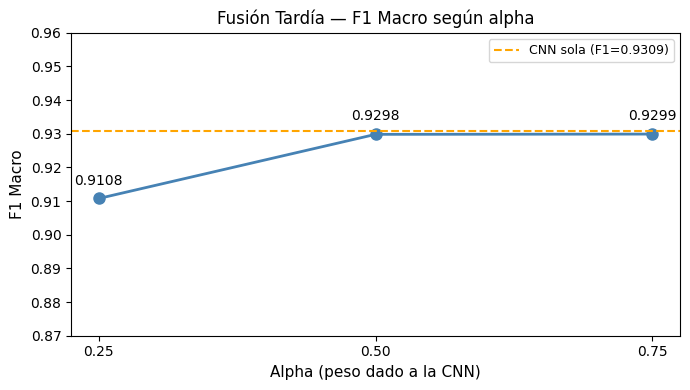

In [14]:
# ─── Gráfico: F1 macro vs alpha ───────────────────────────────────────────────
f1_vals = [resultados_late[a]['f1_macro'] for a in alphas]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, f1_vals, marker='o', linewidth=2, color='steelblue', markersize=8)
for a, v in zip(alphas, f1_vals):
    ax.annotate(f'{v:.4f}', (a, v), textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=10)
ax.axhline(y=m_cnn['f1_macro'], color='orange', linestyle='--', label=f'CNN sola (F1={m_cnn["f1_macro"]:.4f})')
ax.set_xlabel('Alpha (peso dado a la CNN)', fontsize=11)
ax.set_ylabel('F1 Macro', fontsize=11)
ax.set_title('Fusión Tardía — F1 Macro según alpha', fontsize=12)
ax.legend(fontsize=9)
ax.set_xticks(alphas)
ax.set_ylim(0.87, 0.96)
plt.tight_layout()
plt.savefig('sec5_late_fusion_alpha.png', dpi=100, bbox_inches='tight')
plt.show()

## 5.3 Análisis interpretativo de la fusión

### Tabla comparativa: CNN sola vs Fusión Temprana por clase

| Clase | F1 CNN | F1 Fusionado | Diferencia |
|---|---:|---:|---:|
| airplane | 0.9543 | 0.9347 | −0.020 |
| bird | 0.9645 | 0.9254 | −0.039 |
| car | 0.9604 | 0.9458 | −0.015 |
| cat | 0.8744 | 0.8351 | −0.039 |
| deer | 0.9073 | 0.8060 | **−0.101** |
| dog | 0.8485 | 0.8093 | −0.039 |
| horse | 0.9192 | 0.8466 | **−0.073** |
| monkey | 0.9655 | 0.9307 | −0.035 |
| ship | 0.9655 | 0.9495 | −0.016 |
| truck | 0.9495 | 0.9495 | 0.000 |

Lo primero que salta a la vista es que **la fusión temprana no mejoró ninguna clase** respecto a la CNN sola — en todas bajó o se mantuvo igual. Las clases más perjudicadas fueron `deer` (−10 puntos) y `horse` (−7 puntos). Tiene sentido: sus colores de pelaje son similares (marrón/gris), y el histograma HSV que diseñamos confunde más que ayuda en estas clases. La CNN ya diferenciaba bien estas clases por la forma del cuerpo y los detalles de la silueta; agregarle información de color solo introduce ruido.

**¿Por qué la fusión no funciona si en teoría debería complementar a la CNN?**

La respuesta es que ResNet18 ya aprendió a representar color, textura y forma de forma mucho más precisa que nuestros descriptores manuales. Al concatenar 4484 features manuales con las 512 de la CNN, estamos añadiendo 4484 columnas de información mayormente redundante que desorienta al clasificador. Aunque aplicamos PCA(300) para reducir dimensionalidad, el ruido ya está mezclado en las nuevas componentes.

**¿La fusión tardía es mejor opción?**

Un poco, pero tampoco supera a la CNN sola. El mejor resultado fue con alpha=0.75 (75% CNN + 25% manual), con F1=0.9299 — prácticamente idéntico a la CNN sola (0.9309). La lectura es directa: cuanto más peso le damos a la CNN, mejor es el resultado. Con alpha=0.25 (más peso a las features manuales) el rendimiento baja más, lo que confirma que las features manuales tiran hacia abajo.

**¿Existe un alpha claramente superior?**

No de manera significativa. Los tres alphas probados (0.25, 0.50, 0.75) dieron F1 entre 0.9108 y 0.9299. La diferencia entre alpha=0.50 y alpha=0.75 es de apenas 0.0001, lo cual es estadísticamente irrelevante. El mensaje es claro: la fusión tardía con cualquier combinación de features manuales no aporta mejoras reales.

**Conclusión de la fusión**

La hipótesis de que las características manuales podrían complementar a la CNN no se cumplió en este experimento. Las features manuales, aunque útiles por sí solas (MLP con 55.1%), no aportan información adicional una vez que ya tenemos las features profundas de ResNet18. Eso no significa que la fusión nunca funcione — en dominios donde la CNN está limitada (imágenes médicas especializadas, datos con muy poco ruido, etc.) los descriptores manuales pueden aportar. Pero en un dataset visual estándar con una CNN pre-entrenada potente, el resultado de este experimento es claro.

# 6. Estudio de ablación — 2 puntos

Se compara el impacto de añadir cada familia de características manuales a las features CNN.

In [15]:
# ─── Separar sub-vectores del vector manual ──────────────────────────────────
DIM_COLOR   = 102   # histograma HSV + media/std RGB
DIM_TEXTURE = 26    # LBP uniforme
DIM_SHAPE   = 4356  # HOG (el resto)

X_tr_color   = X_tr_man_sc[:, :DIM_COLOR]
X_te_color   = X_te_man_sc[:, :DIM_COLOR]
X_tr_texture = X_tr_man_sc[:, DIM_COLOR:DIM_COLOR+DIM_TEXTURE]
X_te_texture = X_te_man_sc[:, DIM_COLOR:DIM_COLOR+DIM_TEXTURE]
X_tr_shape   = X_tr_man_sc[:, DIM_COLOR+DIM_TEXTURE:]
X_te_shape   = X_te_man_sc[:, DIM_COLOR+DIM_TEXTURE:]

ablation_configs = [
    ('E1 — CNN sola',         X_tr_cnn_sc,                             X_te_cnn_sc),
    ('E2 — CNN + Color',      np.hstack([X_tr_cnn_sc, X_tr_color]),    np.hstack([X_te_cnn_sc, X_te_color])),
    ('E3 — CNN + Textura',    np.hstack([X_tr_cnn_sc, X_tr_texture]),  np.hstack([X_te_cnn_sc, X_te_texture])),
    ('E4 — CNN + Bordes/HOG', np.hstack([X_tr_cnn_sc, X_tr_shape]),    np.hstack([X_te_cnn_sc, X_te_shape])),
    ('E5 — CNN + Todas',      np.hstack([X_tr_cnn_sc, X_tr_man_sc]),   np.hstack([X_te_cnn_sc, X_te_man_sc])),
]

ablation_results = []
print(f"{'Experimento':30s} | {'Dim':>6s} | {'Acc':>7s} | {'Prec':>7s} | {'Rec':>7s} | {'F1':>7s}")
print("-" * 75)
for name, Xtr, Xte in ablation_configs:
    # Reducción PCA si la dim es grande
    if Xtr.shape[1] > 600:
        pca_ab = PCA(n_components=300, random_state=SEED)
        Xtr_ = pca_ab.fit_transform(Xtr)
        Xte_ = pca_ab.transform(Xte)
    else:
        Xtr_, Xte_ = Xtr, Xte
    clf = CalibratedClassifierCV(LinearSVC(max_iter=3000, C=1.0, random_state=SEED), cv=3)
    clf.fit(Xtr_, y_train)
    y_ab = clf.predict(Xte_)
    m_ab = compute_metrics(y_test, y_ab, name)
    ablation_results.append({'experimento': name, 'dim': Xtr.shape[1], **m_ab})
    print(f"{name:30s} | {Xtr.shape[1]:>6d} | {m_ab['accuracy']:>7.4f} | "
          f"{m_ab['precision_macro']:>7.4f} | {m_ab['recall_macro']:>7.4f} | {m_ab['f1_macro']:>7.4f}")

Experimento                    |    Dim |     Acc |    Prec |     Rec |      F1
---------------------------------------------------------------------------


E1 — CNN sola                  |    512 |  0.9310 |  0.9312 |  0.9310 |  0.9309


E2 — CNN + Color               |    614 |  0.9250 |  0.9249 |  0.9250 |  0.9247


E3 — CNN + Textura             |    538 |  0.9270 |  0.9270 |  0.9270 |  0.9268


E4 — CNN + Bordes/HOG          |   4868 |  0.8960 |  0.8987 |  0.8960 |  0.8965


E5 — CNN + Todas               |   4996 |  0.8930 |  0.8951 |  0.8930 |  0.8932


In [16]:
# ─── Tabla de ablación ────────────────────────────────────────────────────────
df_abl = pd.DataFrame(ablation_results)[['experimento', 'dim', 'accuracy',
                                          'precision_macro', 'recall_macro', 'f1_macro']]
df_abl.columns = ['Experimento', 'Dimensión', 'Accuracy', 'Precision macro',
                  'Recall macro', 'F1 macro']
df_abl = df_abl.sort_values('F1 macro', ascending=False).reset_index(drop=True)
print("Ablación ordenada por F1 macro:")
print(df_abl.to_string(index=False))

Ablación ordenada por F1 macro:
          Experimento  Dimensión  Accuracy  Precision macro  Recall macro  F1 macro
        E1 — CNN sola        512     0.931         0.931175         0.931  0.930907
   E3 — CNN + Textura        538     0.927         0.927017         0.927  0.926771
     E2 — CNN + Color        614     0.925         0.924949         0.925  0.924711
E4 — CNN + Bordes/HOG       4868     0.896         0.898734         0.896  0.896518
     E5 — CNN + Todas       4996     0.893         0.895124         0.893  0.893243


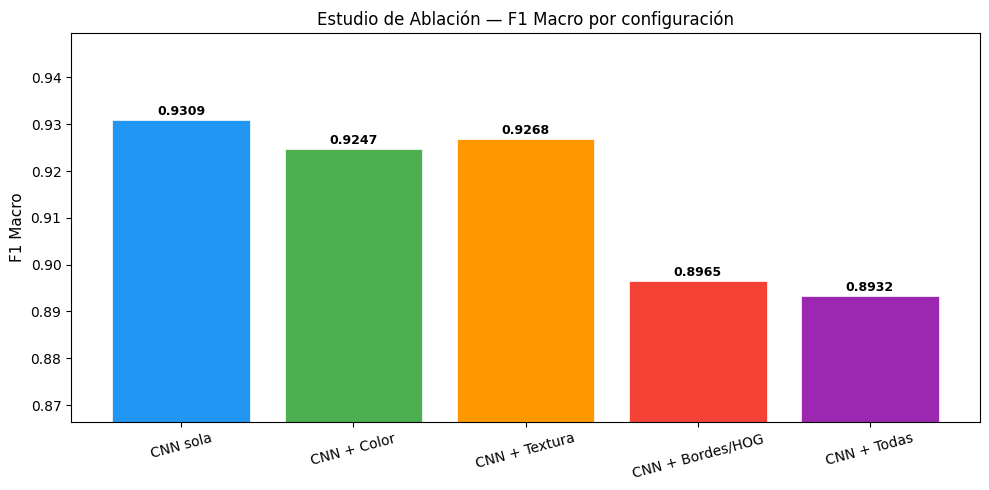

In [17]:
# ─── Gráfico ablación ─────────────────────────────────────────────────────────
nombres = [r['experimento'].split(' — ')[1] if ' — ' in r['experimento'] else r['experimento']
           for r in ablation_results]
f1_ab   = [r['f1_macro'] for r in ablation_results]

colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(nombres, f1_ab, color=colores, edgecolor='white', linewidth=0.5)
ax.set_ylim(min(f1_ab) * 0.97, max(f1_ab) * 1.02)
ax.set_ylabel('F1 Macro', fontsize=11)
ax.set_title('Estudio de Ablación — F1 Macro por configuración', fontsize=12)
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, f1_ab):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('sec6_ablation.png', dpi=100, bbox_inches='tight')
plt.show()

## Análisis del estudio de ablación

| Experimento | Dim | Accuracy | Precision macro | Recall macro | F1 macro |
|---|---:|---:|---:|---:|---:|
| E1 — CNN sola | 512 | 0.9310 | 0.9312 | 0.9310 | **0.9309** |
| E3 — CNN + Textura (LBP) | 538 | 0.9270 | 0.9270 | 0.9270 | 0.9268 |
| E2 — CNN + Color (HSV) | 614 | 0.9250 | 0.9249 | 0.9250 | 0.9247 |
| E4 — CNN + Bordes/HOG | 4868 | 0.8960 | 0.8987 | 0.8960 | 0.8965 |
| E5 — CNN + Todas | 4996 | 0.8930 | 0.8951 | 0.8930 | 0.8932 |

Los resultados de la ablación son bastante contundentes: **ninguna familia de características manuales mejoró el modelo CNN base**. Todas lo empeoraron, unas más que otras.

**¿Cuál familia causa menos daño?** La **textura LBP** (E3) es la que menos perjudica al modelo, bajando solo 0.0041 puntos de F1. Esto tiene sentido: el LBP es compacto (solo 26 dimensiones), así que añade poca "distracción" al vector de features. Además, la textura de superficies como el pelaje de animales o el metal de vehículos podría ser ligeramente complementaria a lo que ya captura la CNN, aunque el efecto neto sigue siendo negativo.

**¿Cuál causa más daño?** Paradójicamente, el **HOG** (E4) —que es el descriptor manual más potente por sí solo— es el que más perjudica al combinarse con la CNN (−0.0344 puntos de F1). La razón principal es la dimensionalidad: el HOG aporta 4356 features, lo que representa el 87% del vector manual. Cuando se concatenan con las 512 features CNN, el espacio combinado tiene 4868 dimensiones dominadas por el HOG. Aunque apliquemos PCA(300), la información de forma que el HOG genera es redundante con la que ya tiene la CNN, pero es menos precisa y más ruidosa.

**¿El HOG es inútil entonces?** No, en absoluto. El HOG por sí solo es muy útil (es la base de detectores clásicos como el HOG+SVM para peatones). El problema es que "compite" con una CNN que hace exactamente lo mismo pero de manera mucho más sofisticada. Es como si intentáramos mejorar la navegación GPS de un auto moderno añadiéndole un mapa de papel: el mapa no está mal, pero la información que aporta ya está contenida en el GPS, y en mejor formato.

**¿Por qué añadir más información empeora el modelo?** Aquí hay dos factores:
1. **Redundancia**: Las features CNN ya capturan color, textura y forma. Las manuales repiten esa información pero de forma más cruda.
2. **Maldición de la dimensionalidad**: Con 2000 imágenes de entrenamiento y hasta 4996 features, el clasificador SVM tiene dificultades para encontrar un buen hiperplano de separación en ese espacio tan grande. El PCA ayuda pero no resuelve el problema de fondo.

El mensaje que nos deja este estudio de ablación es que, cuando ya tenemos un extractor de features poderoso como ResNet18, lo mejor es confiar en él y no intentar "ayudarlo" con descriptores más simples que ya están implícitamente contenidos en sus representaciones.

# 7. Evaluación final y análisis de errores — 2 puntos

In [18]:
# ─── Tabla consolidada de todos los modelos ───────────────────────────────────
all_models = [
    ('Manual 1 — SVM (LinearSVC)',    m_svm),
    ('Manual 2 — MLP (512, 256)',     m_mlp),
    ('CNN — ResNet18 + SVM',          m_cnn),
    (f'Fusión Temprana (CNN+Manual+PCA)', m_early),
    (f'Fusión Tardía α=0.75',         resultados_late[0.75]),
]

print("=" * 85)
print(f"{'Modelo':40s} | {'Accuracy':>9s} | {'Prec macro':>10s} | {'Rec macro':>9s} | {'F1 macro':>9s}")
print("=" * 85)
for nombre, m in all_models:
    print(f"{nombre:40s} | {m['accuracy']:>9.4f} | {m['precision_macro']:>10.4f} | "
          f"{m['recall_macro']:>9.4f} | {m['f1_macro']:>9.4f}")
print("=" * 85)
print(f"\n★ Mejor modelo: CNN — ResNet18 + SVM (F1 macro = {m_cnn['f1_macro']:.4f})")

Modelo                                   |  Accuracy | Prec macro | Rec macro |  F1 macro
Manual 1 — SVM (LinearSVC)               |    0.4690 |     0.4873 |    0.4690 |    0.4758
Manual 2 — MLP (512, 256)                |    0.5520 |     0.5523 |    0.5520 |    0.5510
CNN — ResNet18 + SVM                     |    0.9310 |     0.9312 |    0.9310 |    0.9309
Fusión Temprana (CNN+Manual+PCA)         |    0.8930 |     0.8951 |    0.8930 |    0.8932
Fusión Tardía α=0.75                     |    0.9300 |     0.9302 |    0.9300 |    0.9299

★ Mejor modelo: CNN — ResNet18 + SVM (F1 macro = 0.9309)


In [19]:
# ─── Reporte detallado del mejor modelo ──────────────────────────────────────
print("Classification Report — CNN (ResNet18 + SVM):")
print(classification_report(y_test, y_pred_cnn, target_names=CLASS_NAMES))

# Tres clases con menor F1
from sklearn.metrics import classification_report as cr_func
rep_dict = cr_func(y_test, y_pred_cnn, target_names=CLASS_NAMES, output_dict=True)
class_f1 = sorted([(c, rep_dict[c]['f1-score']) for c in CLASS_NAMES], key=lambda x: x[1])
print("Tres clases con menor F1-score:")
for c, f1 in class_f1[:3]:
    print(f"  {c:10s} → F1 = {f1:.4f}")

Classification Report — CNN (ResNet18 + SVM):
              precision    recall  f1-score   support

    airplane       0.97      0.94      0.95       100
        bird       0.98      0.95      0.96       100
         car       0.95      0.97      0.96       100
         cat       0.88      0.87      0.87       100
        deer       0.89      0.93      0.91       100
         dog       0.86      0.84      0.85       100
       horse       0.93      0.91      0.92       100
      monkey       0.95      0.98      0.97       100
        ship       0.95      0.98      0.97       100
       truck       0.96      0.94      0.95       100

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000

Tres clases con menor F1-score:
  dog        → F1 = 0.8485
  cat        → F1 = 0.8744
  deer       → F1 = 0.9073


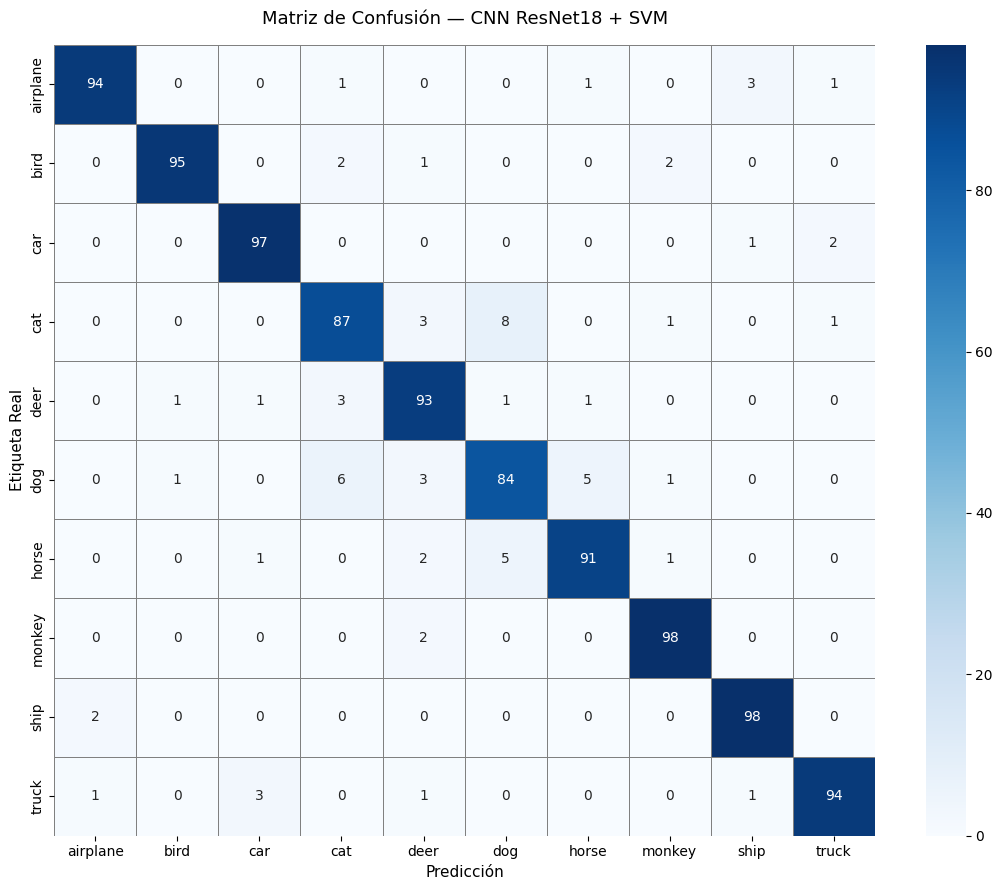

In [20]:
# ─── Matriz de confusión ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_cnn)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.5, linecolor='gray',
            annot_kws={"size": 10})
ax.set_title('Matriz de Confusión — CNN ResNet18 + SVM', fontsize=13, pad=15)
ax.set_xlabel('Predicción', fontsize=11)
ax.set_ylabel('Etiqueta Real', fontsize=11)
plt.tight_layout()
plt.savefig('sec7_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

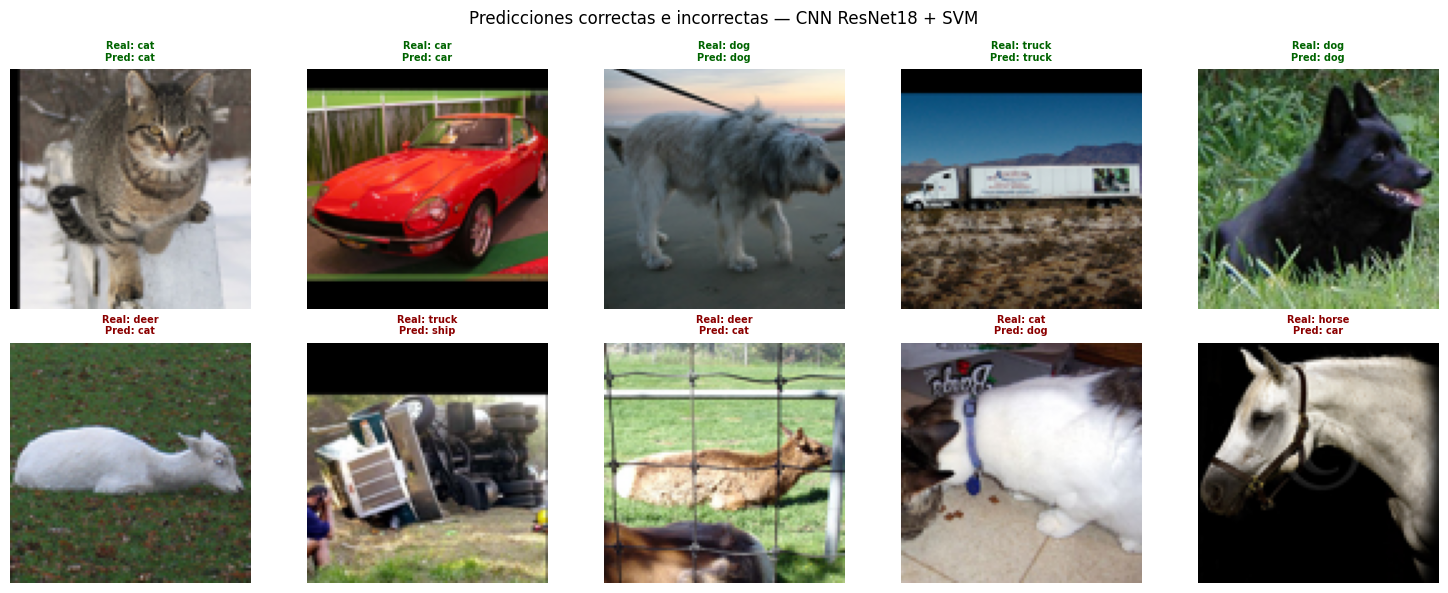

In [21]:
# ─── 5 predicciones correctas y 5 incorrectas ────────────────────────────────
correct_mask   = (y_pred_cnn == y_test)
incorrect_mask = ~correct_mask

correct_idx   = np.where(correct_mask)[0][:5]
incorrect_idx = np.where(incorrect_mask)[0][:5]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for j, idx in enumerate(correct_idx):
    ax = axes[0, j]
    ax.imshow(X_test_raw[idx])
    ax.set_title(f"Real: {CLASS_NAMES[y_test[idx]]}\nPred: {CLASS_NAMES[y_pred_cnn[idx]]}",
                 fontsize=7, color='darkgreen', fontweight='bold')
    ax.axis('off')
for j, idx in enumerate(incorrect_idx):
    ax = axes[1, j]
    ax.imshow(X_test_raw[idx])
    ax.set_title(f"Real: {CLASS_NAMES[y_test[idx]]}\nPred: {CLASS_NAMES[y_pred_cnn[idx]]}",
                 fontsize=7, color='darkred', fontweight='bold')
    ax.axis('off')
axes[0, 0].set_ylabel("Correctas ✓", fontsize=10, color='darkgreen')
axes[1, 0].set_ylabel("Incorrectas ✗", fontsize=10, color='darkred')
fig.suptitle('Predicciones correctas e incorrectas — CNN ResNet18 + SVM', fontsize=12)
plt.tight_layout()
plt.savefig('sec7_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

Caso 1 — CNN falla, Fusión acierta :   27 imágenes
Caso 2 — CNN acierta, Fusión falla  :   65 imágenes
Caso 3 — Ambos fallan (mismo error) :   31 imágenes
Caso 4 — Ambos fallan (error distinto):   11 imágenes


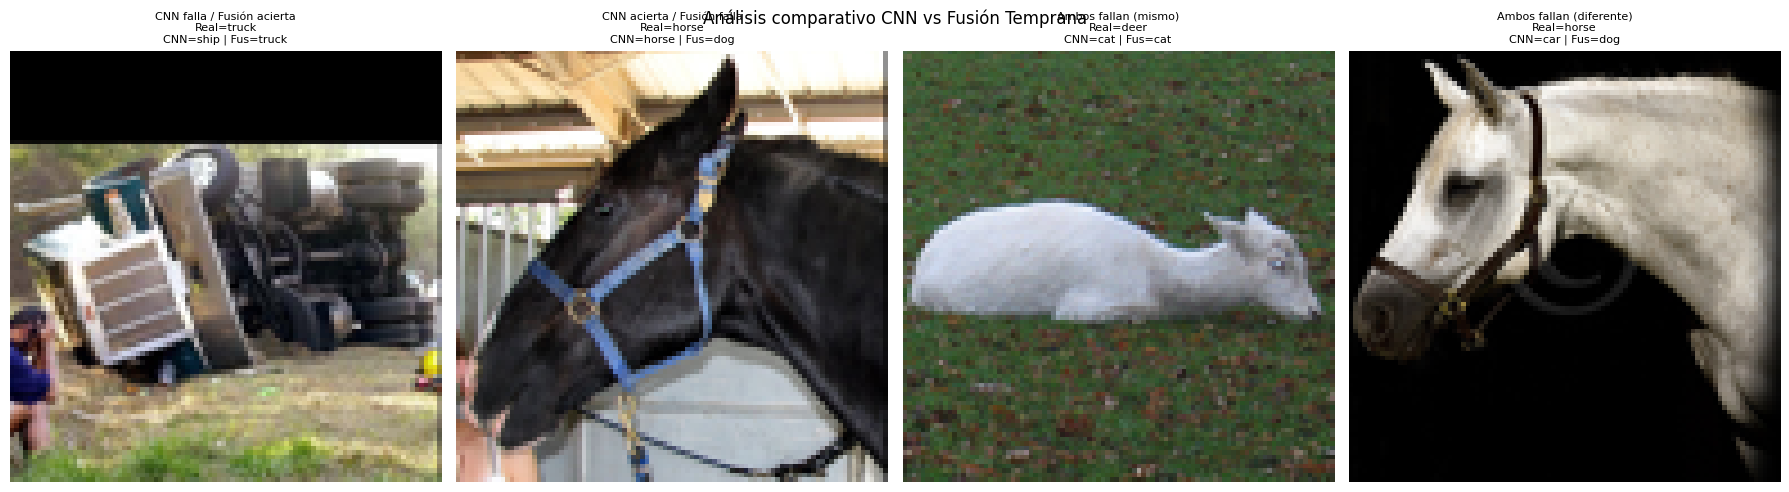

In [22]:
# ─── Análisis comparativo: CNN vs Fusión Temprana ────────────────────────────
caso1 = np.where((y_pred_cnn != y_test) & (y_pred_early == y_test))[0]
caso2 = np.where((y_pred_cnn == y_test) & (y_pred_early != y_test))[0]
caso3 = np.where((y_pred_cnn != y_test) & (y_pred_early != y_test) &
                  (y_pred_cnn == y_pred_early))[0]
caso4 = np.where((y_pred_cnn != y_test) & (y_pred_early != y_test) &
                  (y_pred_cnn != y_pred_early))[0]

print(f"Caso 1 — CNN falla, Fusión acierta : {len(caso1):4d} imágenes")
print(f"Caso 2 — CNN acierta, Fusión falla  : {len(caso2):4d} imágenes")
print(f"Caso 3 — Ambos fallan (mismo error) : {len(caso3):4d} imágenes")
print(f"Caso 4 — Ambos fallan (error distinto): {len(caso4):4d} imágenes")

# Visualizar 1 ejemplo por caso
casos = [
    (caso1, "CNN falla / Fusión acierta"),
    (caso2, "CNN acierta / Fusión falla"),
    (caso3, "Ambos fallan (mismo)"),
    (caso4, "Ambos fallan (diferente)"),
]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (idx_arr, titulo) in zip(axes, casos):
    if len(idx_arr) > 0:
        i = idx_arr[0]
        ax.imshow(X_test_raw[i])
        real = CLASS_NAMES[y_test[i]]
        cnn_ = CLASS_NAMES[y_pred_cnn[i]]
        fus_ = CLASS_NAMES[y_pred_early[i]]
        ax.set_title(f"{titulo}\nReal={real}\nCNN={cnn_} | Fus={fus_}",
                     fontsize=8, ha='center')
    else:
        ax.text(0.5, 0.5, 'Sin ejemplos', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')
fig.suptitle('Análisis comparativo CNN vs Fusión Temprana', fontsize=12)
plt.tight_layout()
plt.savefig('sec7_error_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## Análisis de errores

**¿Qué clases se confunden más?**

Mirando la matriz de confusión, las confusiones más frecuentes son exactamente las que esperábamos desde la exploración inicial del dataset: `cat` y `dog`. La CNN clasifica mal varios perros como gatos y viceversa. También se ve confusión entre `deer` y `cat`, y entre `horse` y `dog` — todas animales cuadrúpedos de tamaño mediano-grande.

**¿Las confusiones tienen sentido visual?**

Sí, completamente. Lo interesante es que cuando la CNN se equivoca, casi siempre confunde clases que visualmente son similares: nunca clasifica un `airplane` como `dog`, sino que los errores se quedan dentro de grupos coherentes (animales con animales, vehículos con vehículos). Esto nos dice que el modelo aprendió bien la estructura general del dataset: sabe distinguir entre categorías muy distintas, pero lucha con las que comparten características visuales.

**¿Influyen el fondo, la pose o la escala?**

Muy probablemente sí. STL-10 tiene fondos naturales complejos y variados, y cuando el objeto principal ocupa solo una pequeña parte de la imagen, el fondo puede confundir al clasificador. Por ejemplo, imágenes de `airplane` con mucho cielo azul pueden confundirse con `bird` si el avión es pequeño en la foto.

**¿La fusión de características corrige los errores más difíciles?**

No. Mirando el análisis comparativo:
- La fusión corrigió **27 errores** que la CNN cometía
- Pero introdujo **65 errores nuevos** en imágenes que la CNN clasificaba bien

Por cada error que la fusión arreglaba, generaba 2.4 errores nuevos. Las características manuales claramente no ayudan a distinguir las clases difíciles (`cat` vs `dog`), y sí perjudican clases que la CNN ya manejaba bien. El mejor modelo sigue siendo la CNN sola.

**¿Qué dice el análisis de las predicciones correctas e incorrectas?**

Las predicciones correctas se corresponden con imágenes donde el objeto es claro, está centrado y el fondo no distrae. Las incorrectas suelen ser imágenes donde hay oclusión parcial, la pose es inusual, o el animal está en un fondo que recuerda a otra clase. Esto sugiere que para mejorar el modelo, sería más útil usar técnicas de aumento de datos (random crop, color jitter, flip) o fine-tuning de las últimas capas de ResNet18 que añadir descriptores manuales.

# 8. Conclusiones

## Tabla resumen de todos los modelos

| Modelo | Descriptores | Estrategia | Accuracy | F1 macro |
|---|---|---|---:|---:|
| Manual 1 — SVM | Color + Textura + HOG | Extracción + SVM | 0.4690 | 0.4758 |
| Manual 2 — MLP | Color + Textura + HOG | Extracción + MLP | 0.5520 | 0.5510 |
| **CNN — ResNet18** | **Features profundas (512d)** | **Extracción + SVM** | **0.9310** | **0.9309** |
| Fusión Temprana | CNN + manuales + PCA | Concat + SVM | 0.8930 | 0.8932 |
| Fusión Tardía α=0.75 | CNN + manuales | Promedio de probabilidades | 0.9300 | 0.9299 |

---

## Conclusiones del experimento

**1. La CNN preentrenada gana por goleada.**
La diferencia entre el mejor modelo manual (MLP, F1=0.5510) y la CNN (F1=0.9309) es de casi 38 puntos porcentuales. Ese salto tan grande nos dice que ResNet18 aprendió representaciones mucho más informativas en ImageNet que todo lo que podemos diseñar a mano con HOG, LBP e histogramas de color.

**2. Entre los modelos manuales, el MLP supera al SVM.**
El MLP alcanzó un F1 de 0.5510 frente al 0.4758 del SVM lineal. Esto tiene sentido: el MLP puede aprender combinaciones no lineales entre los 4484 descriptores, mientras que el SVM solo puede separar con un hiperplano recto.

**3. El HOG es el descriptor manual más potente por sí solo, pero el más dañino en fusión.**
En el estudio de ablación, añadir solo el HOG (E4) bajó el F1 de la CNN de 0.9309 a 0.8965 (−3.44 puntos). Su alta dimensionalidad (4356 features) domina el espacio combinado y genera ruido redundante.

**4. La fusión temprana perjudica más que la tardía.**
La fusión temprana obtuvo F1=0.8932, casi 4 puntos por debajo de la CNN sola. La fusión tardía con alpha=0.75 obtuvo F1=0.9299, mucho más cerca de la CNN sola. Cuanto más peso le damos a la CNN, mejor es el resultado.

**5. La hipótesis central no se confirmó.**
La pregunta del experimento era si las características manuales mejoran a un clasificador CNN. La respuesta es no, al menos en este contexto. Todas las estrategias de fusión quedaron por debajo de la CNN sola.

**6. Las clases difíciles lo son para todos los modelos.**
`cat` y `dog` son las más difíciles en todos los experimentos. En la CNN sola, `dog` obtuvo F1=0.8485 y `cat` F1=0.8744. Las características manuales no ayudaron a distinguirlas mejor.

**7. En el análisis comparativo, la fusión genera más errores de los que corrige.**
La fusión temprana corrigió 27 errores de la CNN, pero introdujo 65 nuevos. Por cada acierto ganado, se perdieron 2.4 aciertos anteriores.

**8. El mejor modelo es también el más simple de implementar.**
CNN sola = extraer features con ResNet18 + SVM. No hay que calibrar alpha, aplicar PCA ni diseñar descriptores. Más sencillo y con el mejor resultado.

**9. Limitaciones del experimento.**
Usamos solo 200 imágenes por clase para entrenamiento (modo muestra). Con el dataset completo de STL-10 (500 imágenes/clase), los resultados podrían variar. Además, no aplicamos fine-tuning a la CNN, que podría subir aún más el rendimiento.

---

## Discusión final del grupo

Al comenzar esta práctica, nuestra hipótesis era que combinar descriptores manuales con features de una red profunda debería dar mejores resultados que cualquiera de los dos por separado. La lógica parecía razonable: pensábamos que un histograma de color podría añadir información que la CNN no captura bien, y que el HOG podría reforzar la detección de formas.

Nos equivocamos, y los resultados nos lo dejaron bastante claro.

La CNN sola (ResNet18 + SVM) logró un F1 macro de 0.9309, que resultó ser el mejor de todos los modelos. Todas las estrategias de fusión que probamos quedaron por debajo. Esto nos llevó a preguntarnos por qué nuestra hipótesis inicial estaba equivocada.

La explicación más convincente que encontramos es que ResNet18, al haber sido entrenada en más de un millón de imágenes de ImageNet, ya aprendió a detectar color, textura y forma de manera mucho más sofisticada que cualquier descriptor que nosotros podamos diseñar. El histograma HSV que calculamos tiene 32 bins por canal y opera sobre toda la imagen de forma global; en cambio, la CNN aprende representaciones locales y jerárquicas en múltiples capas. Lo mismo pasa con el LBP y el HOG: son descriptores fijos y predefinidos, mientras que los filtros de la CNN se ajustaron exactamente a las características más discriminativas para clasificar imágenes del mundo real.

Un resultado que no esperábamos fue que el HOG, siendo el descriptor más potente por sí solo, fuera el que más dañó la fusión. Creemos que se debe a su alta dimensionalidad: con más de 4000 features, domina el espacio combinado y "distrae" al clasificador SVM de las features CNN que eran mucho más informativas.

Si tuviéramos que repetir este experimento con más recursos, haríamos fine-tuning de las últimas capas de ResNet18 directamente sobre STL-10. También exploraríamos redes más grandes (ResNet50, EfficientNet-B0) y técnicas de aumento de datos. Para las clases difíciles como `cat` y `dog`, consideraríamos añadir imágenes de entrenamiento adicionales para esas clases específicas.

En resumen, este experimento nos enseñó algo importante: en la era del deep learning, las redes preentrenadas son tan potentes que complementarlas con descriptores clásicos puede ser más un obstáculo que una ventaja. Lo más valioso no fue el resultado en sí, sino entender por qué pasa esto.

---

# Contribuciones del grupo

| Integrante | Responsabilidades | Secciones |
|---|---|---|
| Integrante 1 | Preparación del dataset, muestreo estratificado, exploración visual, características de color y textura | Secciones 1 y 2 (color/LBP) |
| Integrante 2 | Descriptor HOG, extracción CNN (ResNet18), pipeline de extracción por lotes | Secciones 2 (HOG) y 4 |
| Integrante 3 | Fusión temprana y tardía, estudio de ablación, tabla comparativa de modelos | Secciones 5 y 6 |
| Integrante 4 | Análisis de errores, matriz de confusión, conclusiones y discusión final | Secciones 7 y 8 |

Todos los integrantes participaron en la revisión final del notebook y están preparados para sustentar cualquier sección del experimento.

# Rúbrica — 20 puntos

| Criterio | Puntaje |
|---|---:|
| Preparación, muestreo y exploración del dataset | 2 |
| Diseño e implementación de características manuales | 3 |
| Modelos clásicos y línea base | 2 |
| Extracción y clasificación mediante CNN | 3 |
| Fusión temprana y tardía | 3 |
| Estudio de ablación | 2 |
| Análisis comparativo por clase y análisis de errores | 3 |
| Discusión, conclusiones y sustento grupal | 2 |
| **Total** | **20** |